# Historical Classification Snapshot

Copied from the former FinalProject checkpoint. Saved outputs are historical. Only paths were adapted. This snapshot retains original code issues; use notebooks/02_classification.ipynb for the maintained runnable workflow. This is not a recovered standalone EDA notebook.


In [ ]:
from pathlib import Path
PROJECT_ROOT = next(folder for folder in (Path.cwd(), *Path.cwd().parents)
                    if (folder / "src" / "classification" / "pipeline.py").is_file())


# Diamond Clarity Classification

## Objective

Predict diamond clarity family using physical, categorical, and pricing information.

The original clarity grades are grouped into five ordered families:

**I → SI → VS → VVS → IF**

Three models are compared:

- Artificial Neural Network
- Random Forest
- XGBoost

Three experiments are performed:

1. Physical and categorical features without price
2. Add raw price
3. Add price-relative features and use the final model configurations

Experiments are compared using validation data.

The test set remains untouched until the final model has been selected.

The primary model-selection metric is **Macro F1, Macro Recall, Macro Precision** because the clarity
families are imbalanced.

In [123]:
# Here is all the imports
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from tensorflow.keras.regularizers import l2

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

# Data Cleaning

Before feature engineering and modeling, the dataset is checked for:

- Unnecessary index columns
- Missing values
- Invalid zero or negative dimensions
- Invalid numeric values
- Extreme physical-volume outliers

The same cleaning rules identified during exploratory data analysis are
applied before creating the machine-learning features.

In [124]:
# Import original dataframe from kaggle and print there column names, and original shape
ORIGINAL_DATA_PATH = PROJECT_ROOT / "data" / "diamonds.csv"

original_df = pd.read_csv(ORIGINAL_DATA_PATH)

print("Original Kaggle dataset")
print("Shape:", original_df.shape)
print("Rows:", original_df.shape[0])
print("Columns:", original_df.shape[1])

print("\nColumn names:")
print(original_df.columns.tolist())

Original Kaggle dataset
Shape: (53940, 11)
Rows: 53940
Columns: 11

Column names:
['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


In [125]:
# Remove duplicate rows.
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

clean_df = original_df.drop_duplicates().copy()

print("Shape after removing duplicates:", clean_df.shape)

Duplicate rows found: 142
Shape after removing duplicates: (53940, 11)


In [126]:
# Clean Dataset, unrealstic value + values that have zero in any dimension
clean_df = original_df[
    (original_df["x"] > 0)
    & (original_df["y"] > 0)
    & (original_df["z"] > 0)
].copy()

print("Original shape:", original_df.shape)
print("Cleaned shape:", clean_df.shape)
print("Rows removed:", len(original_df) - len(clean_df))

Original shape: (53940, 11)
Cleaned shape: (53920, 11)
Rows removed: 20


In [127]:
# Remove zero dimensions and physically unrealistic x/y/z values relative to carat weight.
clean_df["Volume_Proxy"] = clean_df["x"] * clean_df["y"] * clean_df["z"]
clean_df["Carat_Per_Volume"] = clean_df["carat"] / clean_df["Volume_Proxy"]

Q1 = clean_df["Carat_Per_Volume"].quantile(0.25)
Q3 = clean_df["Carat_Per_Volume"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

clean_df = clean_df[
    clean_df["Carat_Per_Volume"].between(lower_bound, upper_bound)
].copy()

print("Original shape:", original_df.shape)
print("Cleaned shape:", clean_df.shape)
print("Rows removed:", len(original_df) - len(clean_df))

Original shape: (53940, 11)
Cleaned shape: (53714, 13)
Rows removed: 226


In [128]:
# Delete columns that are not needed.
if "Unnamed: 0" in clean_df.columns:
    clean_df = clean_df.drop(columns="Unnamed: 0")

print("Shape:", clean_df.shape)
print("Columns:", clean_df.columns.tolist())

Shape: (53714, 12)
Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z', 'Volume_Proxy', 'Carat_Per_Volume']


In [129]:
# Use the cleaned dataframe for the rest of the notebook.
diamonds_df = clean_df.copy()

print("Dataset ready for modeling.")
print("Shape:", diamonds_df.shape)

Dataset ready for modeling.
Shape: (53714, 12)


In [130]:
# Keep same order of randomness
RANDOM_STATE = 42

# This the csv that is being used here
DATA_PATH = PROJECT_ROOT / "sideEDA" / "data" / "cleaned" / "diamonds_final_cleaned.csv"

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Defining Final Classes
CLARITY_CLASSES = ["I", "SI", "VS", "VVS", "IF"]

# Mapping Old Classes to New Classes
CLARITY_MAP = {
    "I1": 0,
    "SI2": 1,
    "SI1": 1,
    "VS2": 2,
    "VS1": 2,
    "VVS2": 3,
    "VVS1": 3,
    "IF": 4
}

In [131]:
# Validate the Cleaned Dataset
required_columns = [
    "carat", "cut", "color", "clarity", "depth",
    "table", "price", "x", "y", "z"
]

missing_columns = [
    column for column in required_columns
    if column not in diamonds_df.columns
]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

if diamonds_df.empty:
    raise ValueError("Dataset is empty.")

invalid_dimensions = (
    (diamonds_df["x"] <= 0)
    | (diamonds_df["y"] <= 0)
    | (diamonds_df["z"] <= 0)
).sum()

if invalid_dimensions > 0:
    raise ValueError(f"{invalid_dimensions} rows contain invalid dimensions.")

unknown_clarity = (
    set(diamonds_df["clarity"].dropna().unique())
    - set(CLARITY_MAP.keys())
)

if unknown_clarity:
    raise ValueError(f"Unknown clarity grades: {unknown_clarity}")

print("Dataset validation passed.")

Dataset validation passed.


In [132]:
# Create the Family Classes and Implement the Mapping
diamonds_df["Clarity_Target"] = diamonds_df["clarity"].map(CLARITY_MAP)

if diamonds_df["Clarity_Target"].isna().any():
    raise ValueError("Some clarity grades could not be mapped.")

diamonds_df["Clarity_Family"] = diamonds_df["Clarity_Target"].map(
    dict(enumerate(CLARITY_CLASSES))
)

diamonds_df["Clarity_Family"].value_counts().reindex(CLARITY_CLASSES)

Clarity_Family
I        715
SI     22125
VS     20370
VVS     8714
IF      1790
Name: count, dtype: int64

In [133]:
# Check for missing values.
missing_values = diamonds_df.isna().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


## Physical Feature Engineering
"""
Raw `x`, `y`, and `z` measurements describe the diamond dimensions,
but additional features may represent size and proportions more directly.

The following features are created:

- Face area
- Approximate volume
- Aspect ratio
- XY asymmetry
- Depth relative to face size
- Weight per face area
- Weight per volume
- Table-to-depth ratio """

In [134]:
# Physical engineered features.
diamonds_df["REG_FaceArea"] = diamonds_df["x"] * diamonds_df["y"]
diamonds_df["REG_Volume"] = diamonds_df["x"] * diamonds_df["y"] * diamonds_df["z"]
diamonds_df["REG_AspectRatio"] = diamonds_df["x"] / diamonds_df["y"].replace(0, np.nan)
diamonds_df["REG_XYAsymmetry"] = abs(diamonds_df["x"] - diamonds_df["y"])

face_diagonal = np.sqrt(diamonds_df["x"]**2 + diamonds_df["y"]**2)

diamonds_df["REG_DepthToFace"] = diamonds_df["z"] / face_diagonal.replace(0, np.nan)
diamonds_df["REG_WeightPerFace"] = diamonds_df["carat"] / diamonds_df["REG_FaceArea"].replace(0, np.nan)
diamonds_df["REG_WeightPerVolume"] = diamonds_df["carat"] / diamonds_df["REG_Volume"].replace(0, np.nan)
diamonds_df["REG_TableDepthRatio"] = diamonds_df["table"] / diamonds_df["depth"].replace(0, np.nan)


## Price-Relative Features

Raw price increases heavily with diamond size.

The final feature experiment therefore measures price relative to
physical size.

These features test whether relative market value contains more
clarity information than absolute price alone.


In [135]:
# Generate Price Based Features
diamonds_df["PricePerCarat"] = diamonds_df["price"] / diamonds_df["carat"].replace(0, np.nan)
diamonds_df["PricePerVolume"] = diamonds_df["price"] / diamonds_df["REG_Volume"].replace(0, np.nan)
diamonds_df["PricePerFaceArea"] = diamonds_df["price"] / diamonds_df["REG_FaceArea"].replace(0, np.nan)
diamonds_df["PricePerFaceDiagonal"] = diamonds_df["price"] / face_diagonal.replace(0, np.nan)

diamonds_df = diamonds_df.replace([np.inf, -np.inf], np.nan)

In [136]:
PHYSICAL_FEATURES = [
    "carat", "depth", "table", "x", "y", "z",
    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XYAsymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio"
]

RAW_PRICE_FEATURES = ["price"]

PRICE_RELATIVE_FEATURES = [
    "PricePerCarat",
    "PricePerVolume",
    "PricePerFaceArea",
    "PricePerFaceDiagonal"
]

CATEGORICAL_FEATURES = ["cut", "color"]

In [137]:
EXPERIMENT_1_NUMERIC = PHYSICAL_FEATURES
EXPERIMENT_2_NUMERIC = (PHYSICAL_FEATURES + RAW_PRICE_FEATURES)
EXPERIMENT_3_NUMERIC = (PHYSICAL_FEATURES + RAW_PRICE_FEATURES + PRICE_RELATIVE_FEATURES)

print("Experiment 1:", len(EXPERIMENT_1_NUMERIC), "numeric features")
print("Experiment 2:", len(EXPERIMENT_2_NUMERIC), "numeric features")
print("Experiment 3:", len(EXPERIMENT_3_NUMERIC), "numeric features")

Experiment 1: 14 numeric features
Experiment 2: 15 numeric features
Experiment 3: 19 numeric features


## Data Split and Preprocessing

A single stratified split is created and reused across all three experiments
and all model types.

- Training: 70%
- Validation: 15%
- Testing: 15%

The validation set is used for experiment comparison and model selection.

The test set remains untouched until the final model has been selected.

After splitting the data:

- Categorical features are one-hot encoded.
- Numerical features are imputed where needed.
- Numerical features are scaled for the ANN.
- Tree-based models use the numerical values without standard scaling.

All preprocessing steps are fitted using the training data only to avoid
data leakage.

In [138]:
# Insepct All Three Experiment, Features and Dataypes
# Inspect all three experiments: features and data types.

for experiment_name, numeric_features in {
    "Experiment 1": EXPERIMENT_1_NUMERIC,
    "Experiment 2": EXPERIMENT_2_NUMERIC,
    "Experiment 3": EXPERIMENT_3_NUMERIC,
}.items():

    experiment_features = numeric_features + CATEGORICAL_FEATURES

    print("\n" + "=" * 80)
    print(experiment_name)
    print("=" * 80)

    print("\nFeatures:")
    for feature in experiment_features:
        print(f"- {feature}")

    print("\nData Types:")
    print(diamonds_df[experiment_features].dtypes)

    print("\nTotal Features:", len(experiment_features))


Experiment 1

Features:
- carat
- depth
- table
- x
- y
- z
- REG_FaceArea
- REG_Volume
- REG_AspectRatio
- REG_XYAsymmetry
- REG_DepthToFace
- REG_WeightPerFace
- REG_WeightPerVolume
- REG_TableDepthRatio
- cut
- color

Data Types:
carat                  float64
depth                  float64
table                  float64
x                      float64
y                      float64
z                      float64
REG_FaceArea           float64
REG_Volume             float64
REG_AspectRatio        float64
REG_XYAsymmetry        float64
REG_DepthToFace        float64
REG_WeightPerFace      float64
REG_WeightPerVolume    float64
REG_TableDepthRatio    float64
cut                     object
color                   object
dtype: object

Total Features: 16

Experiment 2

Features:
- carat
- depth
- table
- x
- y
- z
- REG_FaceArea
- REG_Volume
- REG_AspectRatio
- REG_XYAsymmetry
- REG_DepthToFace
- REG_WeightPerFace
- REG_WeightPerVolume
- REG_TableDepthRatio
- price
- cut
- color

Data T

In [139]:
# Target
y = diamonds_df["Clarity_Target"].astype(int).to_numpy()

# Experiment feature lists
EXPERIMENT_1_FEATURES = EXPERIMENT_1_NUMERIC + CATEGORICAL_FEATURES
EXPERIMENT_2_FEATURES = EXPERIMENT_2_NUMERIC + CATEGORICAL_FEATURES
EXPERIMENT_3_FEATURES = EXPERIMENT_3_NUMERIC + CATEGORICAL_FEATURES

# Create all three X datasets upfront
X_1 = diamonds_df[EXPERIMENT_1_FEATURES].copy()
X_2 = diamonds_df[EXPERIMENT_2_FEATURES].copy()
X_3 = diamonds_df[EXPERIMENT_3_FEATURES].copy()

print("Experiment 1:", X_1.shape)
print("Experiment 2:", X_2.shape)
print("Experiment 3:", X_3.shape)
print("Target:", y.shape)

Experiment 1: (53714, 16)
Experiment 2: (53714, 17)
Experiment 3: (53714, 21)
Target: (53714,)


In [140]:
# Create A Shared Split
indices = np.arange(len(diamonds_df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y[temp_idx]
)

y_train = y[train_idx]
y_valid = y[valid_idx]
y_test = y[test_idx]

In [141]:
# Train all 3 Experiment

# Experiment 1
X_train_1 = X_1.iloc[train_idx].copy()
X_valid_1 = X_1.iloc[valid_idx].copy()
X_test_1 = X_1.iloc[test_idx].copy()

# Experiment 2
X_train_2 = X_2.iloc[train_idx].copy()
X_valid_2 = X_2.iloc[valid_idx].copy()
X_test_2 = X_2.iloc[test_idx].copy()

# Experiment 3
X_train_3 = X_3.iloc[train_idx].copy()
X_valid_3 = X_3.iloc[valid_idx].copy()
X_test_3 = X_3.iloc[test_idx].copy()

In [142]:
print("Experiment 1")
print("Train:", X_train_1.shape)
print("Valid:", X_valid_1.shape)
print("Test: ", X_test_1.shape)

print("\nExperiment 2")
print("Train:", X_train_2.shape)
print("Valid:", X_valid_2.shape)
print("Test: ", X_test_2.shape)

print("\nExperiment 3")
print("Train:", X_train_3.shape)
print("Valid:", X_valid_3.shape)
print("Test: ", X_test_3.shape)

print("\nTargets")
print("Train:", y_train.shape)
print("Valid:", y_valid.shape)
print("Test: ", y_test.shape)

Experiment 1
Train: (37599, 16)
Valid: (8057, 16)
Test:  (8058, 16)

Experiment 2
Train: (37599, 17)
Valid: (8057, 17)
Test:  (8058, 17)

Experiment 3
Train: (37599, 21)
Valid: (8057, 21)
Test:  (8058, 21)

Targets
Train: (37599,)
Valid: (8057,)
Test:  (8058,)


## Preprocessing for All Three Experiments

Each experiment uses the same preprocessing approach so the models receive
clean and consistent input data.

### Numerical Features

For all numerical features:

- Missing values are filled using the **median** calculated from the training set.
- Numerical features are standardized using **StandardScaler**.
- Standardization transforms each feature to approximately:
  - Mean = 0
  - Standard deviation = 1

Scaling is especially important for the Artificial Neural Network because
features such as `price`, `carat`, dimensions, and engineered ratios are on
very different numerical scales.

### Categorical Features

The categorical features are:

- `cut`
- `color`

For these features:

- Missing values are filled using the most frequent category.
- Categories are converted into numerical inputs using **One-Hot Encoding**.
- Unknown categories encountered in validation or test data are ignored safely.

### Data Leakage Prevention

The preprocessing pipeline is fitted using the **training set only**.

The fitted preprocessing steps are then applied to:

- Validation data
- Test data

This prevents information from the validation or test sets from influencing
the preprocessing of the training data.

### Experiment Feature Sets

- **Experiment 1:** Physical + categorical features
- **Experiment 2:** Physical + raw price + categorical features
- **Experiment 3:** Physical + raw price + price-relative features + categorical features

In [143]:
# Scale numeric features and one-hot encode categorical features.
def create_preprocessor(numeric_features):
    return ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), CATEGORICAL_FEATURES)
    ])

In [144]:
preprocessor_1 = create_preprocessor(EXPERIMENT_1_NUMERIC)

X_train_processed_1 = preprocessor_1.fit_transform(X_train_1).astype(np.float32)
X_valid_processed_1 = preprocessor_1.transform(X_valid_1).astype(np.float32)
X_test_processed_1 = preprocessor_1.transform(X_test_1).astype(np.float32)

print("Experiment 1")
print("Train:", X_train_processed_1.shape)
print("Valid:", X_valid_processed_1.shape)
print("Test: ", X_test_processed_1.shape)

Experiment 1
Train: (37599, 26)
Valid: (8057, 26)
Test:  (8058, 26)


In [145]:
preprocessor_2 = create_preprocessor(EXPERIMENT_2_NUMERIC)

X_train_processed_2 = preprocessor_2.fit_transform(X_train_2).astype(np.float32)
X_valid_processed_2 = preprocessor_2.transform(X_valid_2).astype(np.float32)
X_test_processed_2 = preprocessor_2.transform(X_test_2).astype(np.float32)

print("Experiment 2")
print("Train:", X_train_processed_2.shape)
print("Valid:", X_valid_processed_2.shape)
print("Test: ", X_test_processed_2.shape)

Experiment 2
Train: (37599, 27)
Valid: (8057, 27)
Test:  (8058, 27)


In [146]:
preprocessor_3 = create_preprocessor(EXPERIMENT_3_NUMERIC)

X_train_processed_3 = preprocessor_3.fit_transform(X_train_3).astype(np.float32)
X_valid_processed_3 = preprocessor_3.transform(X_valid_3).astype(np.float32)
X_test_processed_3 = preprocessor_3.transform(X_test_3).astype(np.float32)

print("Experiment 3")
print("Train:", X_train_processed_3.shape)
print("Valid:", X_valid_processed_3.shape)
print("Test: ", X_test_processed_3.shape)

Experiment 3
Train: (37599, 31)
Valid: (8057, 31)
Test:  (8058, 31)


In [147]:
train_processed_df_1 = pd.DataFrame(
    X_train_processed_1,
    columns=preprocessor_1.get_feature_names_out()
)

train_processed_df_2 = pd.DataFrame(
    X_train_processed_2,
    columns=preprocessor_2.get_feature_names_out()
)

train_processed_df_3 = pd.DataFrame(
    X_train_processed_3,
    columns=preprocessor_3.get_feature_names_out()
)

display(train_processed_df_1)
display(train_processed_df_2)
display(train_processed_df_3)

,numeric__carat,numeric__depth,numeric__table,numeric__x,numeric__y,numeric__z,numeric__REG_FaceArea,numeric__REG_Volume,numeric__REG_AspectRatio,numeric__REG_XYAsymmetry,...,categorical__cut_Ideal,categorical__cut_Premium,categorical__cut_Very Good,categorical__color_D,categorical__color_E,categorical__color_F,categorical__color_G,categorical__color_H,categorical__color_I,categorical__color_J
0,-0.879738,-1.458459,1.604171,-0.926960,-0.899531,-1.051964,-0.890565,-0.880410,-0.881875,-0.235894,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.985547,-0.096299,-1.101231,-1.132384,-1.133354,-1.124379,-1.059017,-0.976178,-0.180086,-1.450214,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.723160,-0.383070,-1.101231,1.689960,1.654535,1.612885,1.770177,1.816127,0.817633,0.168879,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.160238,0.333856,0.251470,0.019776,-0.027191,0.034251,-0.096735,-0.168689,1.062139,0.168879,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.006709,0.620627,0.251470,-1.168110,-1.223286,-1.138862,-1.105547,-1.001148,1.363381,0.168879,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37594,-0.816253,0.405549,-0.199430,-0.846577,-0.881545,-0.820238,-0.851493,-0.813647,0.784997,-0.640668,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37595,0.262998,-0.311377,-0.199430,0.439555,0.485420,0.425289,0.369791,0.259431,-0.827468,0.168879,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
37596,2.590792,0.118778,1.604171,2.082945,2.059229,2.090820,2.291672,2.519238,0.635121,-0.235894,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37597,0.559262,0.047086,-1.101231,0.725362,0.755216,0.729429,0.667227,0.576666,-0.442890,-0.640668,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,numeric__carat,numeric__depth,numeric__table,numeric__x,numeric__y,numeric__z,numeric__REG_FaceArea,numeric__REG_Volume,numeric__REG_AspectRatio,numeric__REG_XYAsymmetry,...,categorical__cut_Ideal,categorical__cut_Premium,categorical__cut_Very Good,categorical__color_D,categorical__color_E,categorical__color_F,categorical__color_G,categorical__color_H,categorical__color_I,categorical__color_J
0,-0.879738,-1.458459,1.604171,-0.926960,-0.899531,-1.051964,-0.890565,-0.880410,-0.881875,-0.235894,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.985547,-0.096299,-1.101231,-1.132384,-1.133354,-1.124379,-1.059017,-0.976178,-0.180086,-1.450214,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.723160,-0.383070,-1.101231,1.689960,1.654535,1.612885,1.770177,1.816127,0.817633,0.168879,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.160238,0.333856,0.251470,0.019776,-0.027191,0.034251,-0.096735,-0.168689,1.062139,0.168879,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.006709,0.620627,0.251470,-1.168110,-1.223286,-1.138862,-1.105547,-1.001148,1.363381,0.168879,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37594,-0.816253,0.405549,-0.199430,-0.846577,-0.881545,-0.820238,-0.851493,-0.813647,0.784997,-0.640668,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37595,0.262998,-0.311377,-0.199430,0.439555,0.485420,0.425289,0.369791,0.259431,-0.827468,0.168879,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
37596,2.590792,0.118778,1.604171,2.082945,2.059229,2.090820,2.291672,2.519238,0.635121,-0.235894,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37597,0.559262,0.047086,-1.101231,0.725362,0.755216,0.729429,0.667227,0.576666,-0.442890,-0.640668,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,numeric__carat,numeric__depth,numeric__table,numeric__x,numeric__y,numeric__z,numeric__REG_FaceArea,numeric__REG_Volume,numeric__REG_AspectRatio,numeric__REG_XYAsymmetry,...,categorical__cut_Ideal,categorical__cut_Premium,categorical__cut_Very Good,categorical__color_D,categorical__color_E,categorical__color_F,categorical__color_G,categorical__color_H,categorical__color_I,categorical__color_J
0,-0.879738,-1.458459,1.604171,-0.926960,-0.899531,-1.051964,-0.890565,-0.880410,-0.881875,-0.235894,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.985547,-0.096299,-1.101231,-1.132384,-1.133354,-1.124379,-1.059017,-0.976178,-0.180086,-1.450214,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.723160,-0.383070,-1.101231,1.689960,1.654535,1.612885,1.770177,1.816127,0.817633,0.168879,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.160238,0.333856,0.251470,0.019776,-0.027191,0.034251,-0.096735,-0.168689,1.062139,0.168879,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.006709,0.620627,0.251470,-1.168110,-1.223286,-1.138862,-1.105547,-1.001148,1.363381,0.168879,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37594,-0.816253,0.405549,-0.199430,-0.846577,-0.881545,-0.820238,-0.851493,-0.813647,0.784997,-0.640668,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37595,0.262998,-0.311377,-0.199430,0.439555,0.485420,0.425289,0.369791,0.259431,-0.827468,0.168879,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
37596,2.590792,0.118778,1.604171,2.082945,2.059229,2.090820,2.291672,2.519238,0.635121,-0.235894,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37597,0.559262,0.047086,-1.101231,0.725362,0.755216,0.729429,0.667227,0.576666,-0.442890,-0.640668,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [148]:
# Generate the Descriptive Statstics for all 3 Dataframe
print("=" * 100)
print("EXPERIMENT 1 — DESCRIPTIVE STATISTICS")
print("=" * 100)
display(train_processed_df_1.describe().T)

print("=" * 100)
print("EXPERIMENT 2 — DESCRIPTIVE STATISTICS")
print("=" * 100)
display(train_processed_df_2.describe().T)

print("=" * 100)
print("EXPERIMENT 3 — DESCRIPTIVE STATISTICS")
print("=" * 100)
display(train_processed_df_3.describe().T)

EXPERIMENT 1 — DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
numeric__carat,37599.0,-1.217489e-09,1.000018,-1.260650,-0.837414,-0.202561,0.516939,7.055926
numeric__depth,37599.0,-2.840808e-09,1.000019,-12.714203,-0.526455,0.047086,0.548934,7.503119
numeric__table,37599.0,3.246637e-09,0.999967,-6.512036,-0.650331,-0.199430,0.702370,16.934786
numeric__x,37599.0,1.014574e-09,1.000017,-1.784381,-0.909097,-0.033813,0.725362,3.940690
numeric__y,37599.0,-4.058296e-10,1.000020,-1.843816,-0.908524,-0.027191,0.719243,3.929812
numeric__z,37599.0,-4.058296e-10,0.999995,-1.877488,-0.907136,-0.023680,0.714947,4.190837
numeric__REG_FaceArea,37599.0,-4.058296e-10,1.000018,-1.524449,-0.887019,-0.118126,0.647530,5.122786
numeric__REG_Volume,37599.0,-6.087445e-10,1.000015,-1.281544,-0.844635,-0.194887,0.539280,6.598154
numeric__REG_AspectRatio,37599.0,-3.551009e-10,1.000010,-4.606681,-0.761936,-0.411932,0.854122,9.667288
numeric__REG_XYAsymmetry,37599.0,7.710764e-09,0.999947,-1.854988,-0.640668,-0.235894,0.573652,18.383677


EXPERIMENT 2 — DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
numeric__carat,37599.0,-1.217489e-09,1.000018,-1.260650,-0.837414,-0.202561,0.516939,7.055926
numeric__depth,37599.0,-2.840808e-09,1.000019,-12.714203,-0.526455,0.047086,0.548934,7.503119
numeric__table,37599.0,3.246637e-09,0.999967,-6.512036,-0.650331,-0.199430,0.702370,16.934786
numeric__x,37599.0,1.014574e-09,1.000017,-1.784381,-0.909097,-0.033813,0.725362,3.940690
numeric__y,37599.0,-4.058296e-10,1.000020,-1.843816,-0.908524,-0.027191,0.719243,3.929812
numeric__z,37599.0,-4.058296e-10,0.999995,-1.877488,-0.907136,-0.023680,0.714947,4.190837
numeric__REG_FaceArea,37599.0,-4.058296e-10,1.000018,-1.524449,-0.887019,-0.118126,0.647530,5.122786
numeric__REG_Volume,37599.0,-6.087445e-10,1.000015,-1.281544,-0.844635,-0.194887,0.539280,6.598154
numeric__REG_AspectRatio,37599.0,-3.551009e-10,1.000010,-4.606681,-0.761936,-0.411932,0.854122,9.667288
numeric__REG_XYAsymmetry,37599.0,7.710764e-09,0.999947,-1.854988,-0.640668,-0.235894,0.573652,18.383677


EXPERIMENT 3 — DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
numeric__carat,37599.0,-1.217489e-09,1.000018,-1.260650,-0.837414,-0.202561,0.516939,7.055926
numeric__depth,37599.0,-2.840808e-09,1.000019,-12.714203,-0.526455,0.047086,0.548934,7.503119
numeric__table,37599.0,3.246637e-09,0.999967,-6.512036,-0.650331,-0.199430,0.702370,16.934786
numeric__x,37599.0,1.014574e-09,1.000017,-1.784381,-0.909097,-0.033813,0.725362,3.940690
numeric__y,37599.0,-4.058296e-10,1.000020,-1.843816,-0.908524,-0.027191,0.719243,3.929812
numeric__z,37599.0,-4.058296e-10,0.999995,-1.877488,-0.907136,-0.023680,0.714947,4.190837
numeric__REG_FaceArea,37599.0,-4.058296e-10,1.000018,-1.524449,-0.887019,-0.118126,0.647530,5.122786
numeric__REG_Volume,37599.0,-6.087445e-10,1.000015,-1.281544,-0.844635,-0.194887,0.539280,6.598154
numeric__REG_AspectRatio,37599.0,-3.551009e-10,1.000010,-4.606681,-0.761936,-0.411932,0.854122,9.667288
numeric__REG_XYAsymmetry,37599.0,7.710764e-09,0.999947,-1.854988,-0.640668,-0.235894,0.573652,18.383677


In [152]:
# Plot distributions of the top 8 model-important features.

# Plot distributions of ALL columns in a processed DataFrame.

def plot_all_feature_distributions(processed_df, experiment_name):
    columns = processed_df.columns

    n_cols = 4
    n_rows = int(np.ceil(len(columns) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, n_rows * 4)
    )

    axes = np.array(axes).flatten()

    for i, column in enumerate(columns):
        clean_name = (
            column
            .replace("numeric__", "")
            .replace("categorical__", "")
        )

        axes[i].hist(
            processed_df[column],
            bins=30
        )

        axes[i].set_title(clean_name)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    # Hide unused plots.
    for i in range(len(columns), len(axes)):
        axes[i].axis("off")

    plt.suptitle(
        f"{experiment_name} — Feature Distributions",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

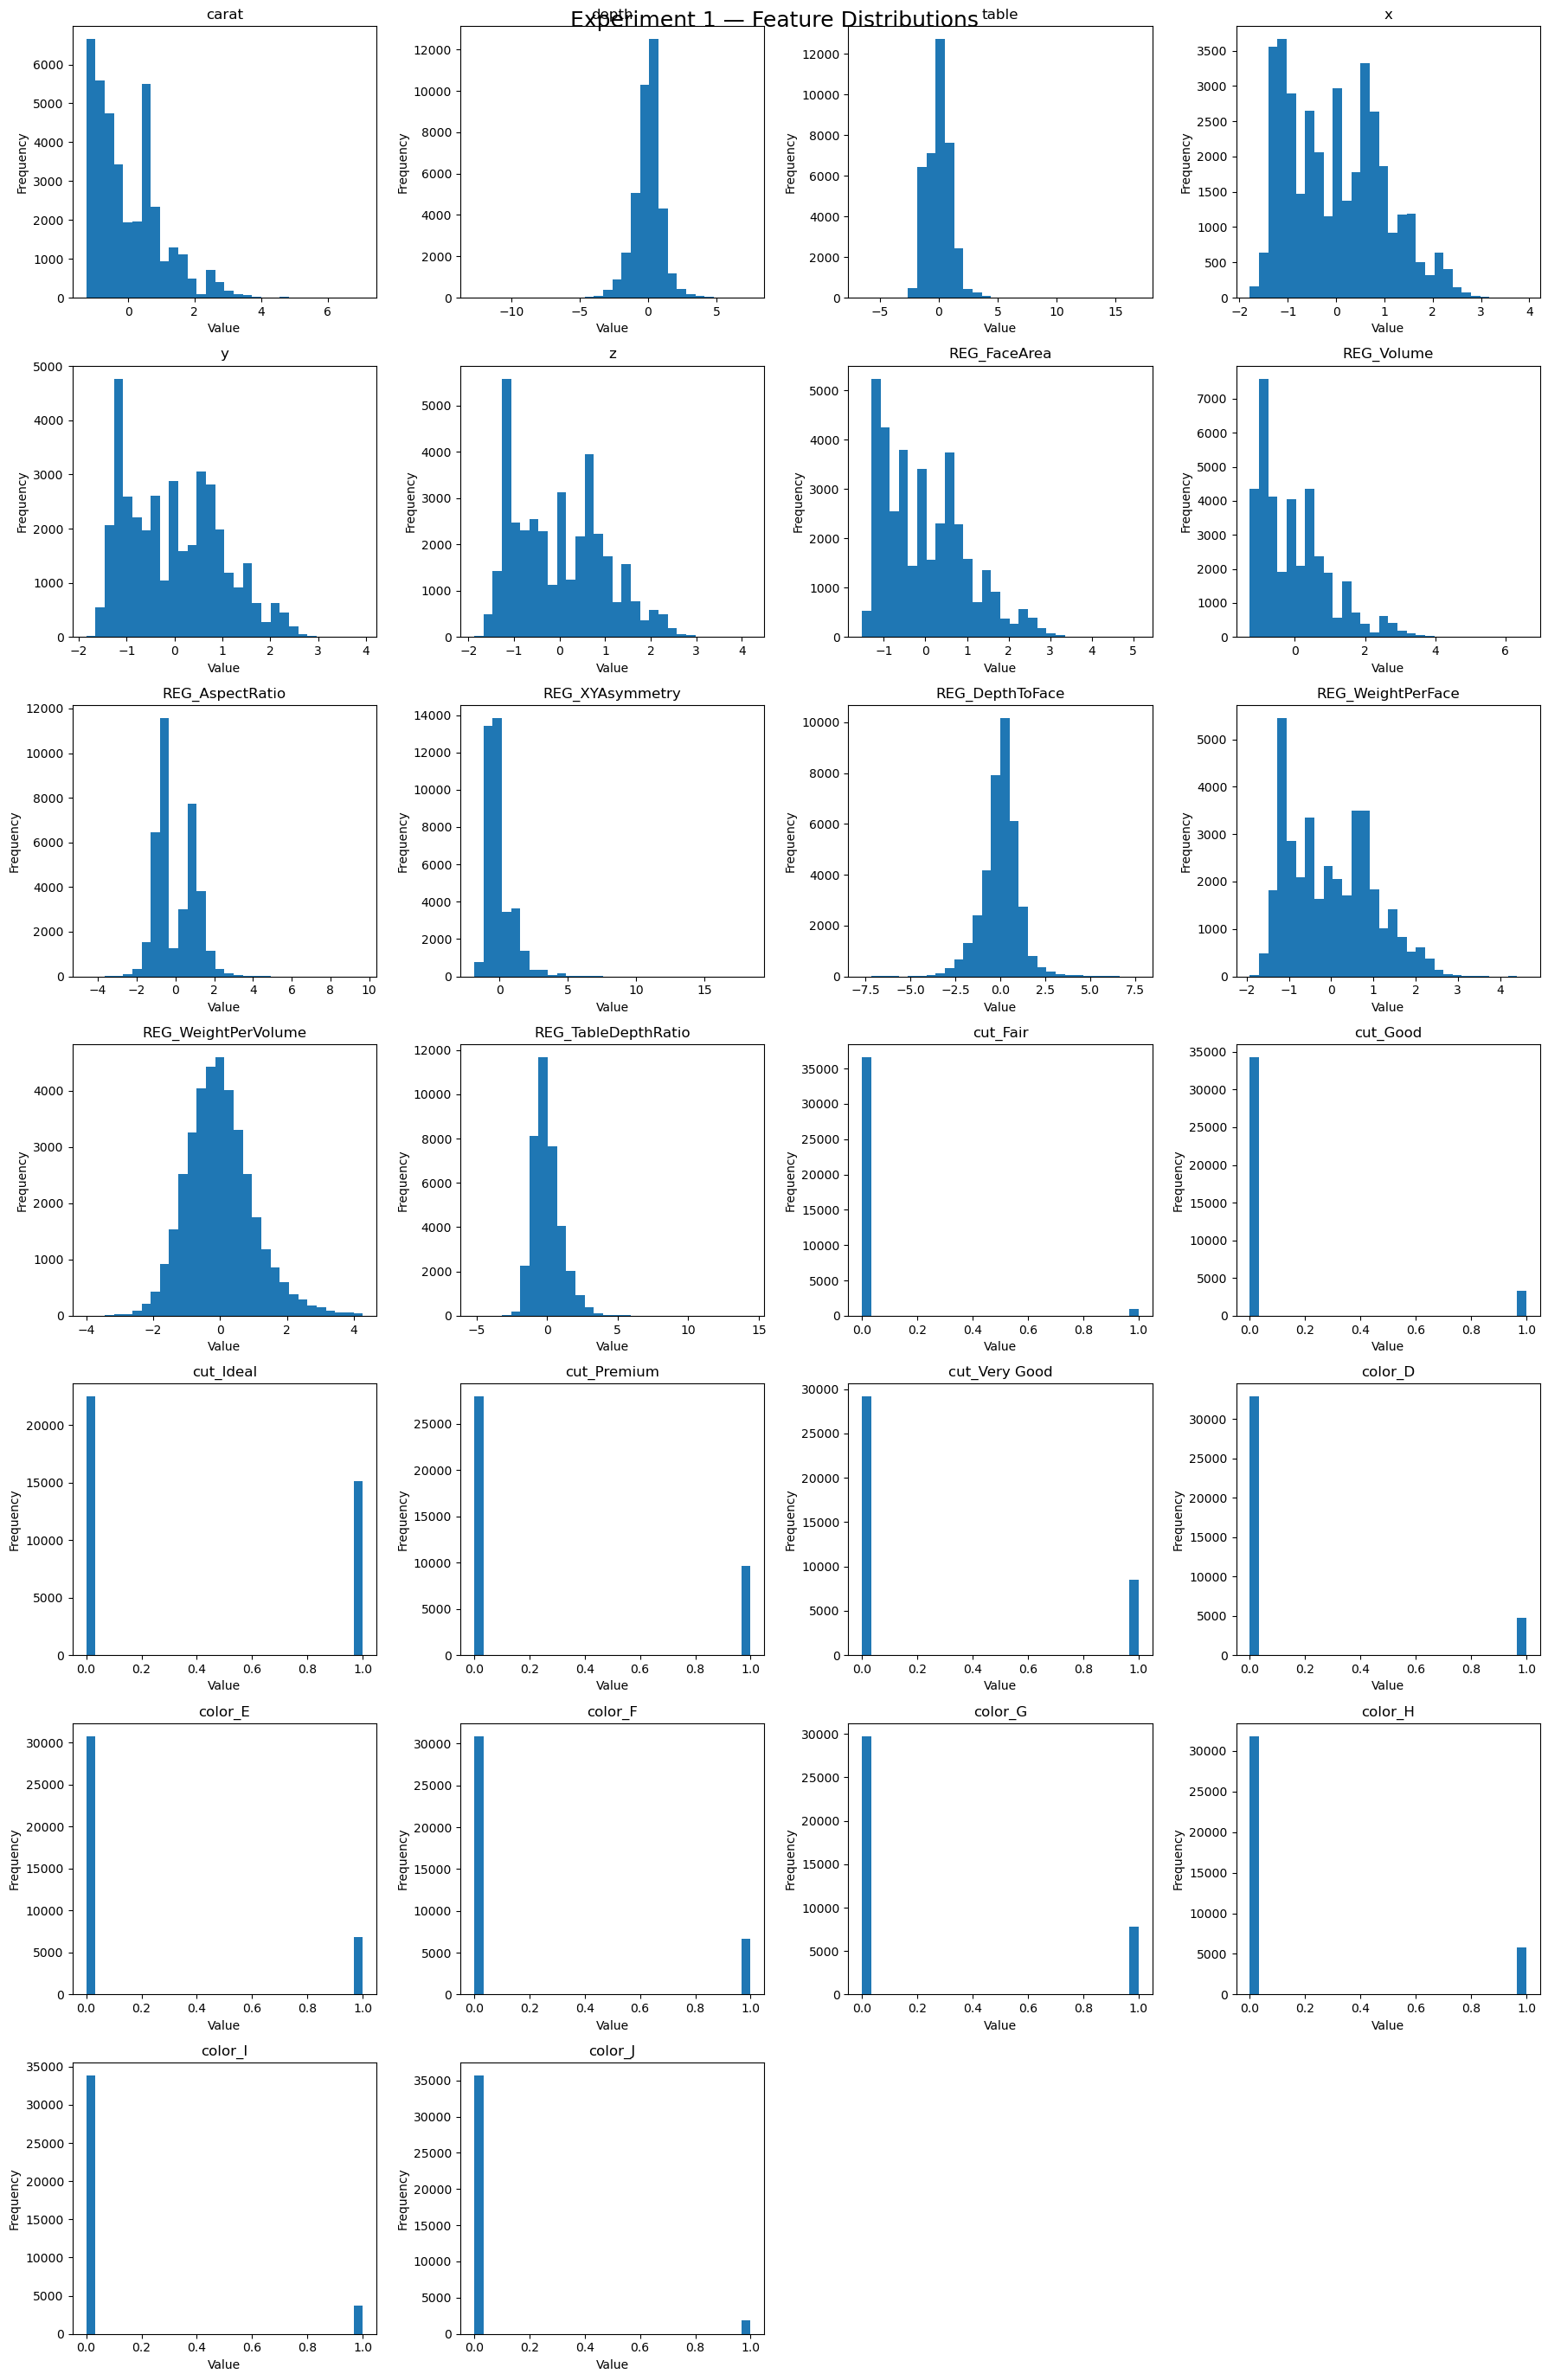

In [153]:
# Graph the distributions of all columns in DataFrame 1.
plot_all_feature_distributions(
    train_processed_df_1,
    "Experiment 1"
)

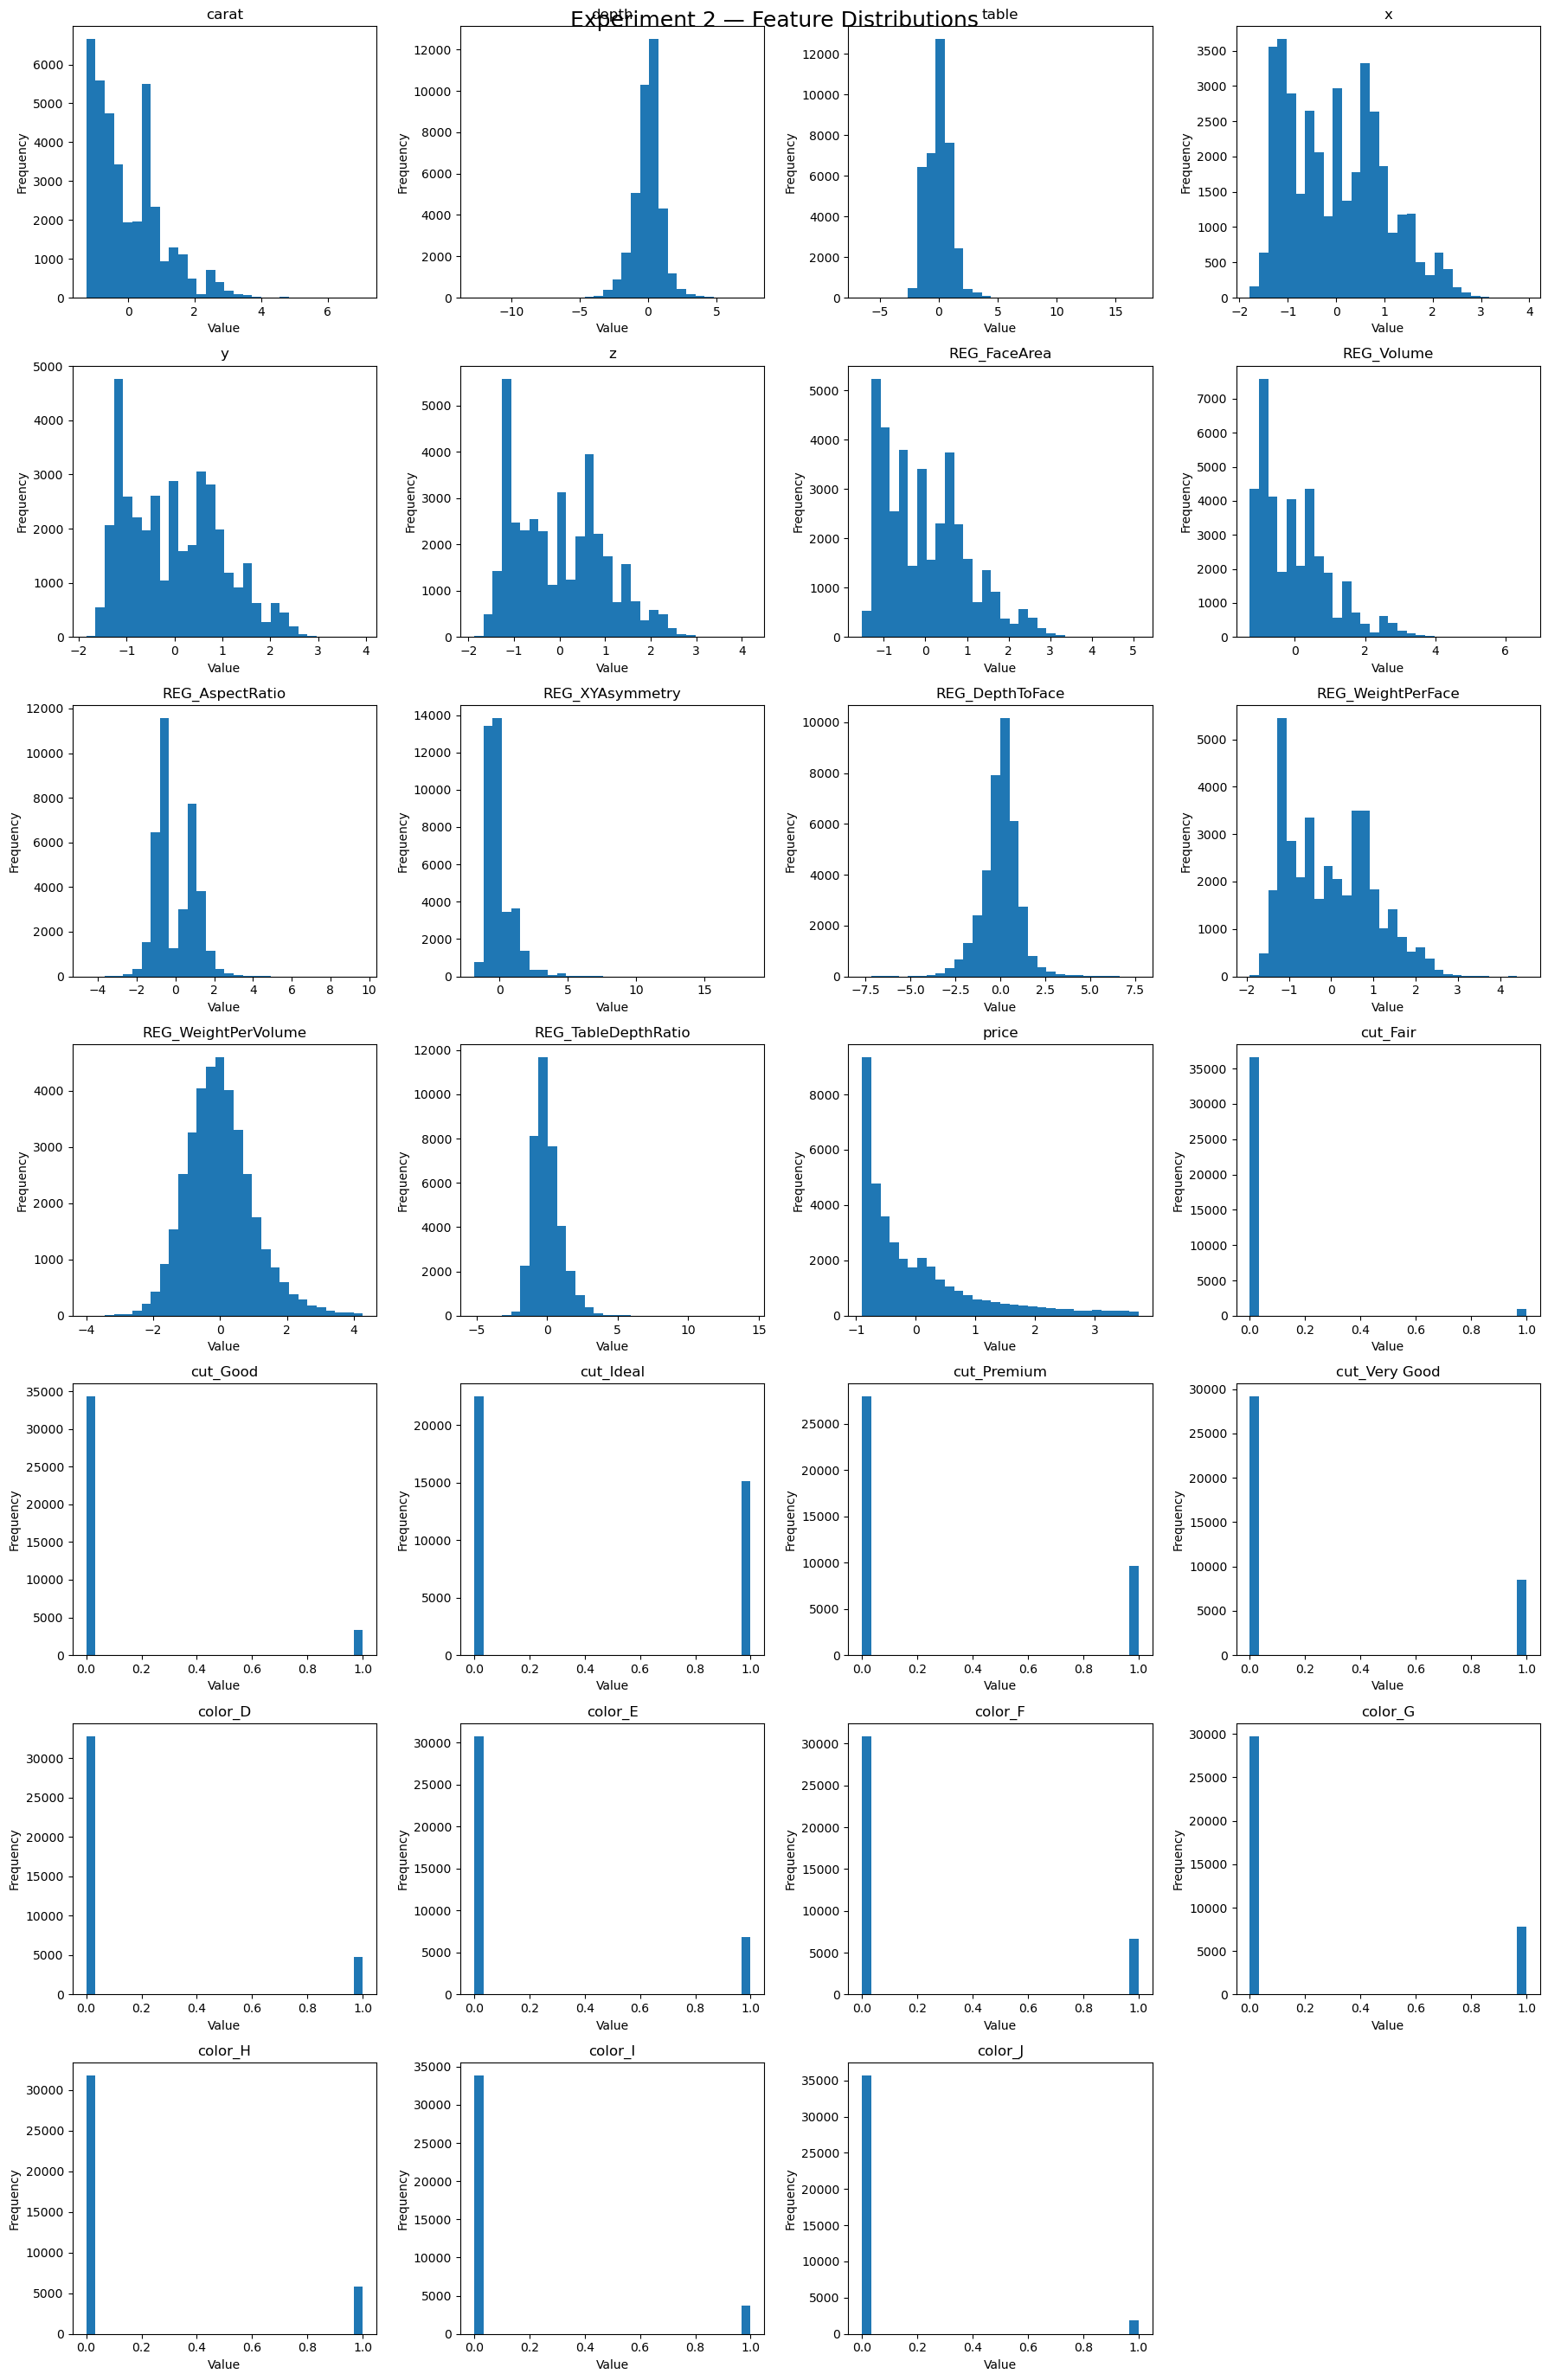

In [154]:
# Graph the distributions of all columns in DataFrame 2.
plot_all_feature_distributions(
    train_processed_df_2,
    "Experiment 2"
)

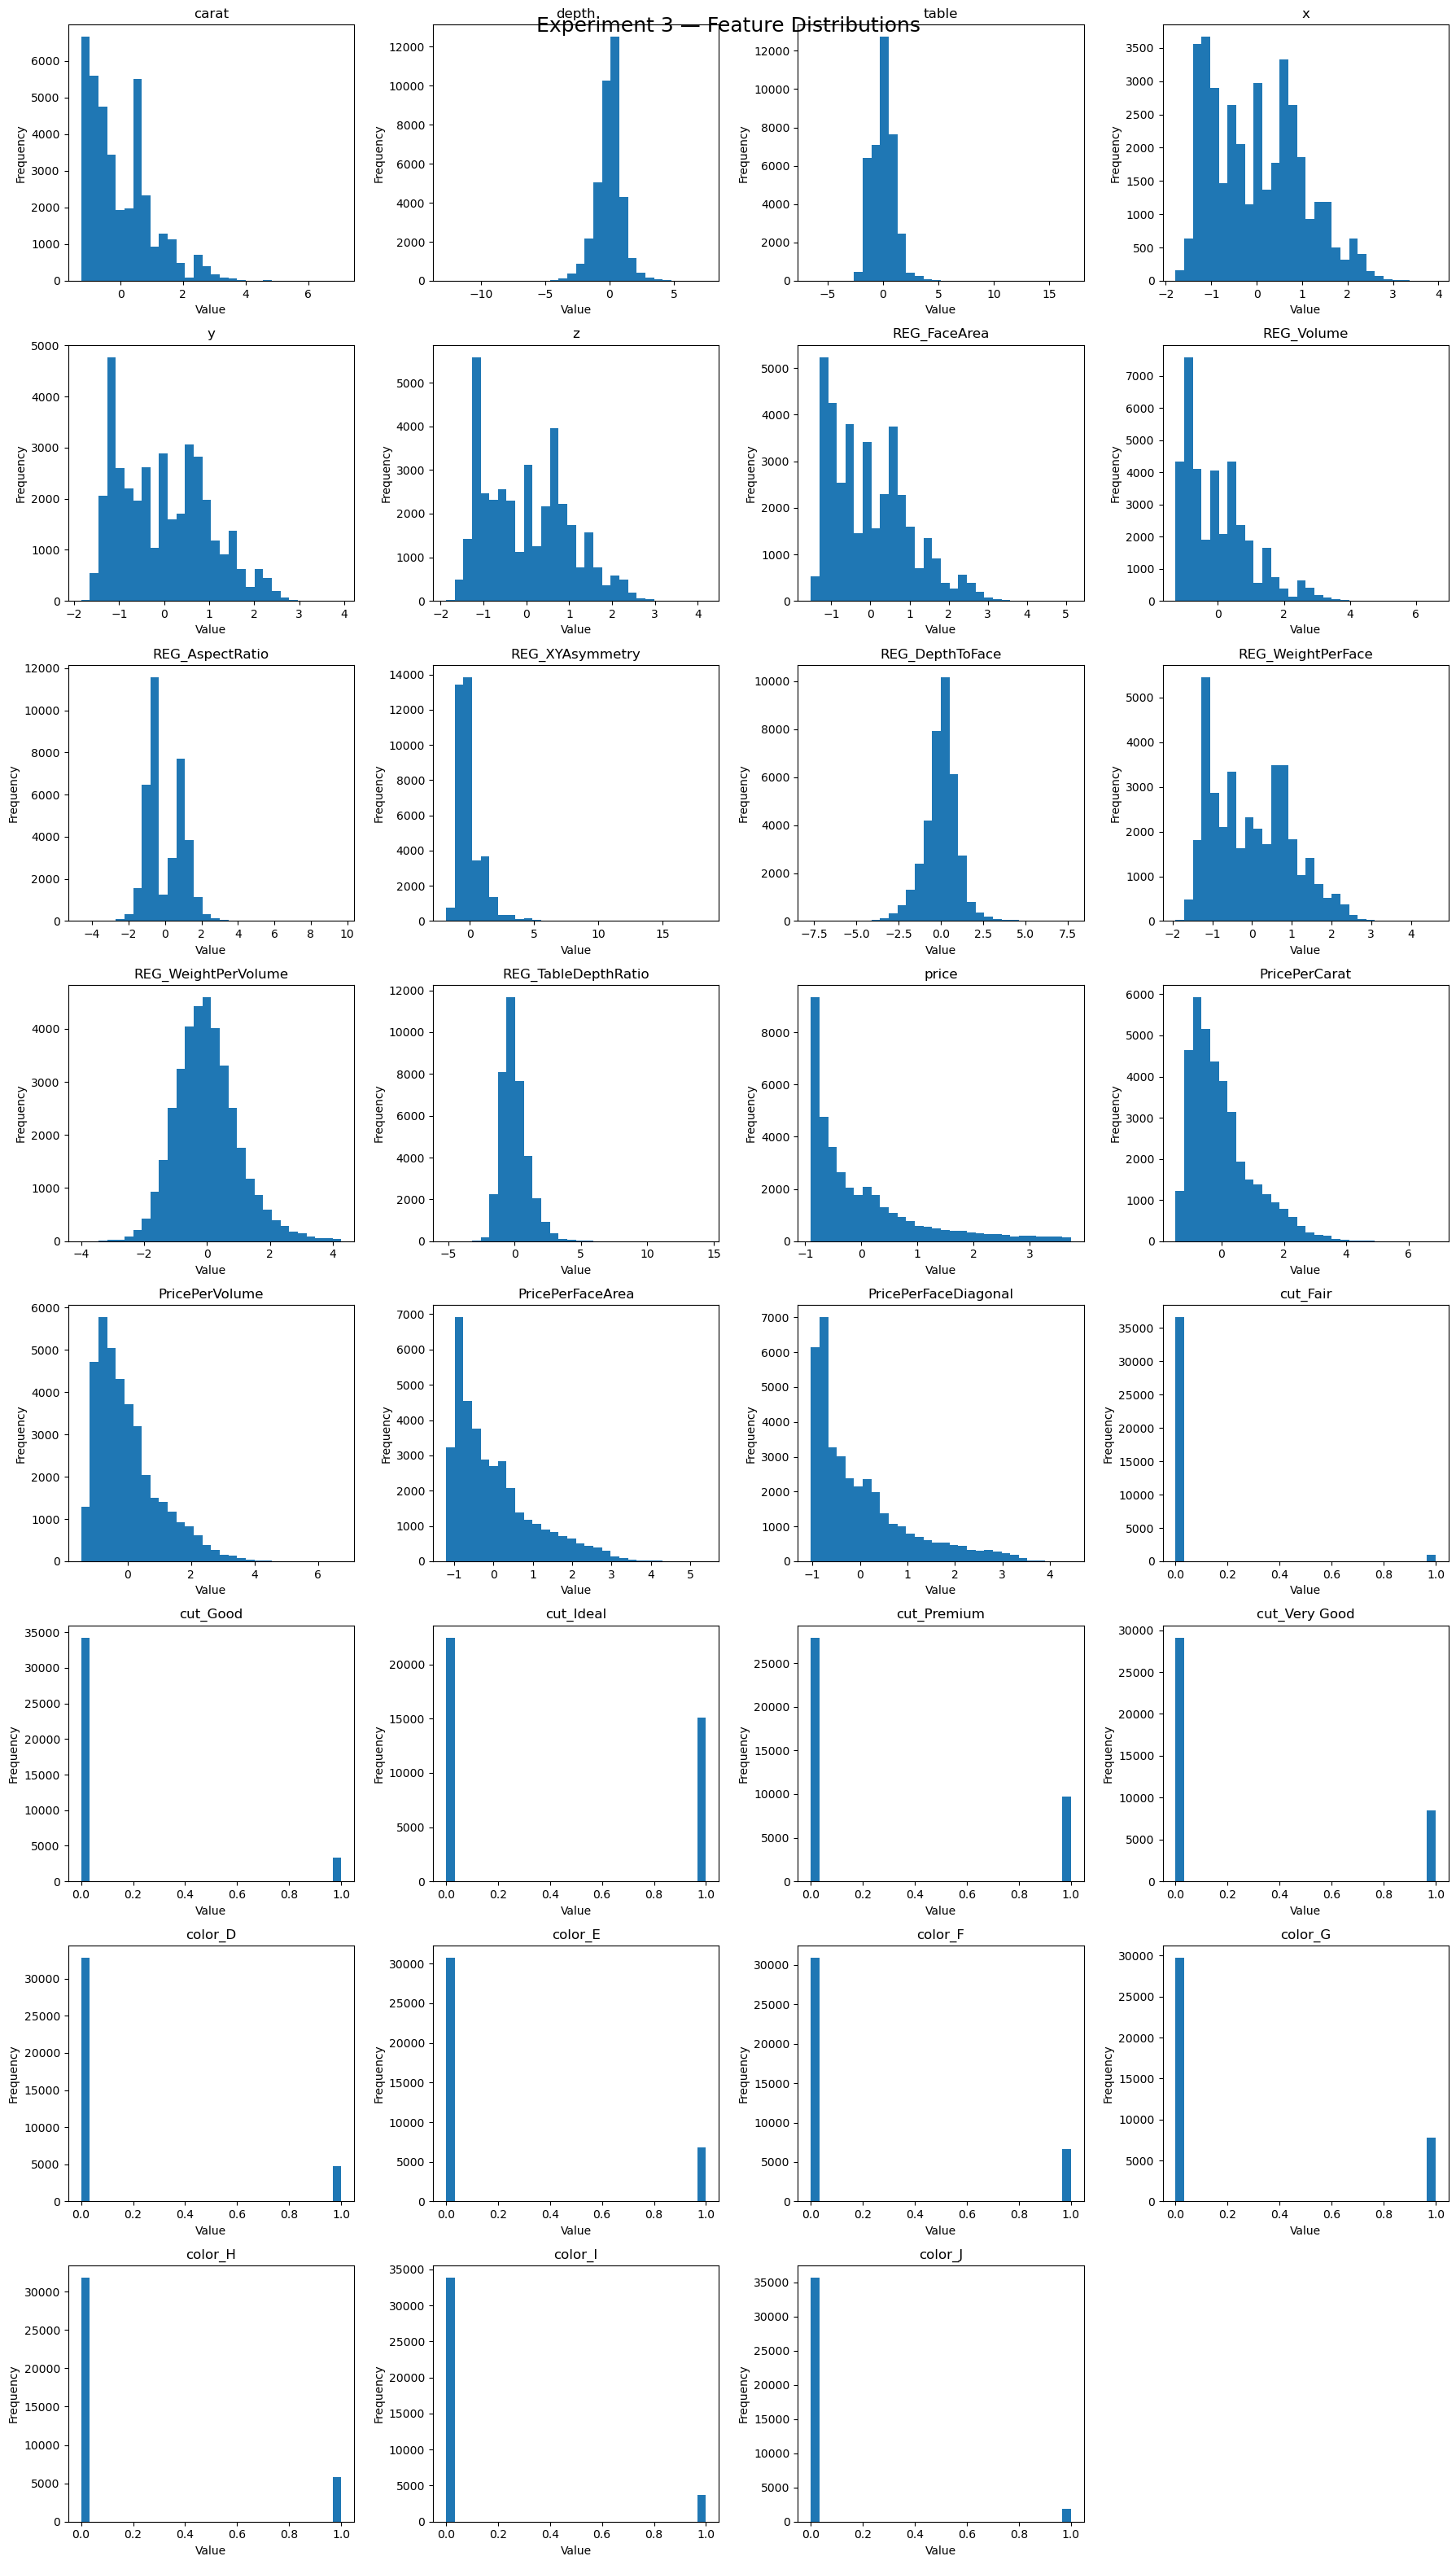

In [155]:
# Graph the distributions of all columns in DataFrame 3.
plot_all_feature_distributions(
    train_processed_df_3,
    "Experiment 3"
)

In [156]:
# Plot Corrleation Matrix Function
def plot_correlation_matrix(
    processed_df,
    y_train,
    features,
    experiment_name
):
    correlation_df = processed_df[list(features)].copy()

    correlation_df["Clarity_Target"] = y_train

    correlation_matrix = correlation_df.corr()

    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    image = ax.imshow(
        correlation_matrix,
        vmin=-1,
        vmax=1
    )

    labels = [
        column
        .replace("numeric__", "")
        .replace("categorical__", "")
        for column in correlation_matrix.columns
    ]

    ax.set_xticks(
        np.arange(len(labels))
    )

    ax.set_yticks(
        np.arange(len(labels))
    )

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j,
                i,
                f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_title(
        f"{experiment_name} — Top Feature Correlation Matrix"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Pearson Correlation"
    )

    plt.tight_layout()
    plt.show()

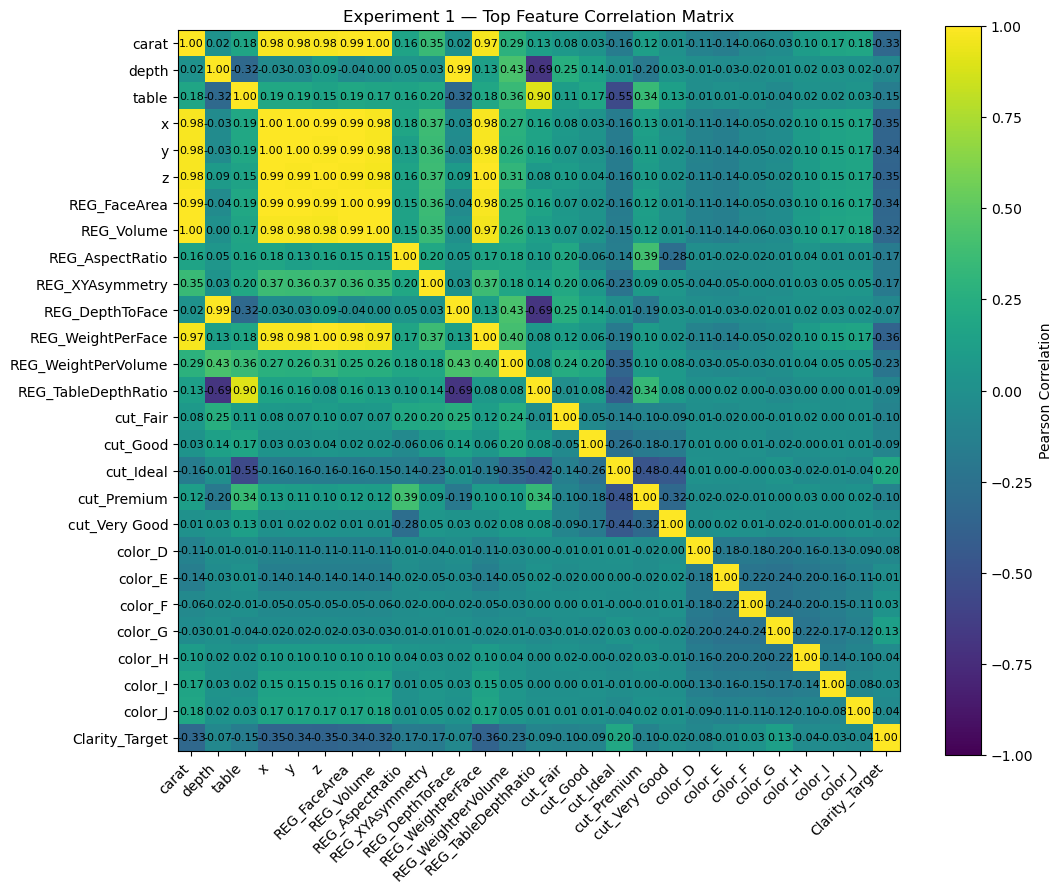

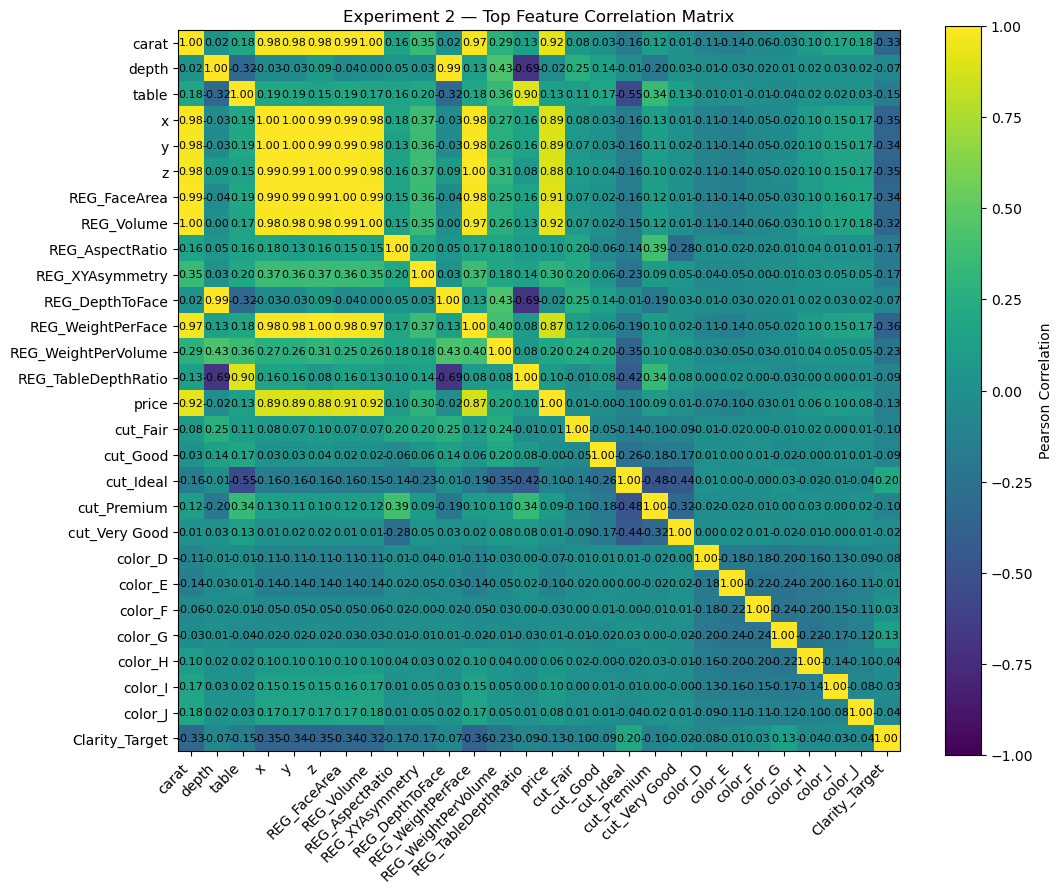

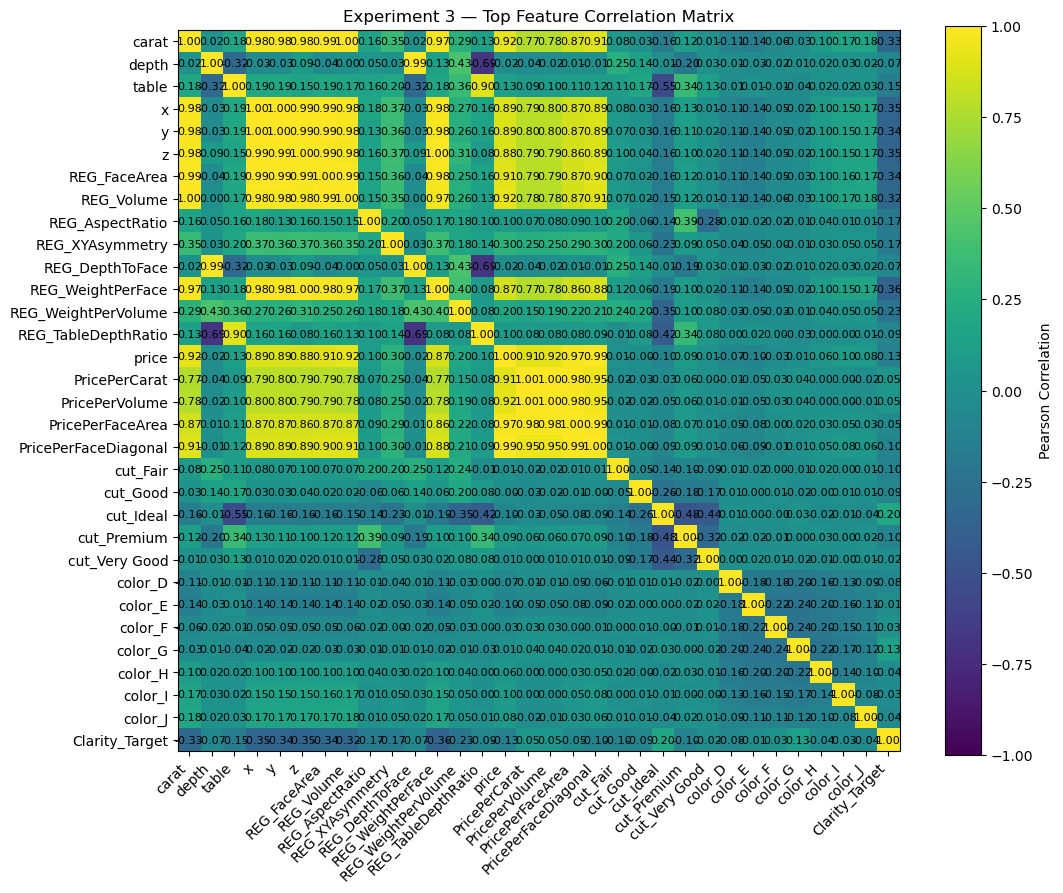

In [158]:
# Correlation Matrix for All 3 DataFrames

# Matrix 01
plot_correlation_matrix(
    train_processed_df_1,
    y_train,
    train_processed_df_1.columns,
    "Experiment 1"
)

# Matrix 02
plot_correlation_matrix(
    train_processed_df_2,
    y_train,
    train_processed_df_2.columns,
    "Experiment 2"
)

# Matrix 03
plot_correlation_matrix(
    train_processed_df_3,
    y_train,
    train_processed_df_3.columns,
    "Experiment 3"
)

# Classification Experiments

Three feature experiments are evaluated using the same three classification models:

- Artificial Neural Network (ANN)
- Random Forest
- XGBoost

All experiments use the same stratified training, validation, and testing split.

The validation set is used to compare models and select the final model.

The test set remains untouched until the final model has been selected.

The primary model-selection metric is **Macro F1** because the clarity
families are not equally represented.

In [159]:
# Double Check if We Have the imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Dense, Dropout

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

In [160]:
# This function is used when we want evaluate the model for experiment
def evaluate_model(y_true, y_pred, experiment_name, model_name):
    family_error = np.abs(y_true - y_pred)

    return {
        "Experiment": experiment_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Macro_Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ) * 100,
        "Macro_Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ) * 100,
        "Macro_F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ) * 100,
        "Weighted_F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true, y_pred
        ) * 100,
        "Mean_Family_Error": family_error.mean(),
        "Within_1_Family": (family_error <= 1).mean() * 100,
        "Severe_Error": (family_error > 1).mean() * 100
    }

In [161]:
# Bulid the Acc Model for experiment, ANN only is bulit cuz other models are already bulit
def build_ann(input_dim):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [162]:
# These are callbacks, setup for the model, so that they have with better results not noise
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6
)

In [163]:
# Storing the Results
results = []
trained_models = {}

## Experiment 1 — Physical Features

Experiment 1 evaluates whether diamond clarity can be predicted using
physical measurements, engineered physical features, cut, and color.

Price information is excluded.

### Models

- Artificial Neural Network
- Random Forest
- XGBoost

In [164]:
ann_1 = build_ann(X_train_processed_1.shape[1])

history_ann_1 = ann_1.fit(
    X_train_processed_1,
    y_train,
    validation_data=(X_valid_processed_1, y_valid),
    epochs=160,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

ann_pred_1 = np.argmax(
    ann_1.predict(X_valid_processed_1, verbose=0),
    axis=1
)

results.append(
    evaluate_model(
        y_valid,
        ann_pred_1,
        "Experiment 1",
        "ANN"
    )
)

trained_models["Experiment 1 - ANN"] = {
    "model": ann_1,
    "experiment": 1,
    "type": "ANN"
}

Epoch 1/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4684 - loss: 1.1503 - val_accuracy: 0.4966 - val_loss: 1.0829 - learning_rate: 0.0010
Epoch 2/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4914 - loss: 1.0960 - val_accuracy: 0.4987 - val_loss: 1.0756 - learning_rate: 0.0010
Epoch 3/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4939 - loss: 1.0867 - val_accuracy: 0.5018 - val_loss: 1.0711 - learning_rate: 0.0010
Epoch 4/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5001 - loss: 1.0793 - val_accuracy: 0.5002 - val_loss: 1.0684 - learning_rate: 0.0010
Epoch 5/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5029 - loss: 1.0745 - val_accuracy: 0.5042 - val_loss: 1.0661 - learning_rate: 0.0010
Epoch 6/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5030 - loss: 1.0714 - val_accuracy: 0.5044 - val_loss: 1.0629 - learning_rate: 0.0010
Epoch 7/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5059 - loss: 1.

In [165]:
rf_1 = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_1.fit(
    X_train_processed_1,
    y_train
)

rf_pred_1 = rf_1.predict(
    X_valid_processed_1
)

results.append(
    evaluate_model(
        y_valid,
        rf_pred_1,
        "Experiment 1",
        "Random Forest"
    )
)

trained_models["Experiment 1 - Random Forest"] = {
    "model": rf_1,
    "experiment": 1,
    "type": "Tree"
}

In [166]:
xgb_weights_1 = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_1 = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=1800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=4,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_1.fit(
    X_train_processed_1,
    y_train,
    sample_weight=xgb_weights_1,
    eval_set=[
        (X_valid_processed_1, y_valid)
    ],
    verbose=False
)

xgb_pred_1 = xgb_1.predict(
    X_valid_processed_1
)

results.append(
    evaluate_model(
        y_valid,
        xgb_pred_1,
        "Experiment 1",
        "XGBoost"
    )
)

trained_models["Experiment 1 - XGBoost"] = {
    "model": xgb_1,
    "experiment": 1,
    "type": "Tree"
}

In [167]:
experiment_1_results = pd.DataFrame(results)

experiment_1_results = experiment_1_results[
    experiment_1_results["Experiment"] == "Experiment 1"
].copy()

display(
    experiment_1_results.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Experiment,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Balanced_Accuracy,Mean_Family_Error,Within_1_Family,Severe_Error
2,Experiment 1,XGBoost,52.525754,42.587931,45.365775,43.514435,52.787075,45.365775,0.592901,89.512225,10.487775
1,Experiment 1,Random Forest,56.000993,52.383504,38.432051,41.657179,54.870122,38.432051,0.526871,92.155889,7.844111
0,Experiment 1,ANN,52.103761,51.544042,31.146947,32.799901,50.039887,31.146947,0.548964,93.421869,6.578131


In [168]:
# Top 8 Features Corrleation 

## Experiment 2 — Physical Features + Raw Price

Experiment 2 adds the raw diamond price to the physical and categorical
features from Experiment 1.

The purpose is to determine whether price provides useful information
for distinguishing diamond clarity families.

### Models

- Artificial Neural Network
- Random Forest
- XGBoost

In [169]:
ann_2 = build_ann(X_train_processed_2.shape[1])

history_ann_2 = ann_2.fit(
    X_train_processed_2,
    y_train,
    validation_data=(X_valid_processed_2, y_valid),
    epochs=160,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

ann_pred_2 = np.argmax(
    ann_2.predict(X_valid_processed_2, verbose=0),
    axis=1
)

results.append(
    evaluate_model(
        y_valid,
        ann_pred_2,
        "Experiment 2",
        "ANN"
    )
)

trained_models["Experiment 2 - ANN"] = {
    "model": ann_2,
    "experiment": 2,
    "type": "ANN"
}

Epoch 1/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5038 - loss: 1.0914 - val_accuracy: 0.5780 - val_loss: 0.9390 - learning_rate: 0.0010
Epoch 2/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5886 - loss: 0.9164 - val_accuracy: 0.6560 - val_loss: 0.8065 - learning_rate: 0.0010
Epoch 3/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6383 - loss: 0.8126 - val_accuracy: 0.7013 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 4/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6757 - loss: 0.7434 - val_accuracy: 0.7318 - val_loss: 0.6592 - learning_rate: 0.0010
Epoch 5/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6994 - loss: 0.6956 - val_accuracy: 0.7531 - val_loss: 0.6205 - learning_rate: 0.0010
Epoch 6/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7184 - loss: 0.6581 - val_accuracy: 0.7679 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 7/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7327 - loss: 0.

In [170]:
rf_2 = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_2.fit(
    X_train_processed_2,
    y_train
)

rf_pred_2 = rf_2.predict(
    X_valid_processed_2
)

results.append(
    evaluate_model(
        y_valid,
        rf_pred_2,
        "Experiment 2",
        "Random Forest"
    )
)

trained_models["Experiment 2 - Random Forest"] = {
    "model": rf_2,
    "experiment": 2,
    "type": "Tree"
}

In [171]:
xgb_weights_2 = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_2 = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=1800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=4,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_2.fit(
    X_train_processed_2,
    y_train,
    sample_weight=xgb_weights_2,
    eval_set=[
        (X_valid_processed_2, y_valid)
    ],
    verbose=False
)

xgb_pred_2 = xgb_2.predict(
    X_valid_processed_2
)

results.append(
    evaluate_model(
        y_valid,
        xgb_pred_2,
        "Experiment 2",
        "XGBoost"
    )
)

trained_models["Experiment 2 - XGBoost"] = {
    "model": xgb_2,
    "experiment": 2,
    "type": "Tree"
}

In [172]:
all_results = pd.DataFrame(results)

experiment_2_results = all_results[
    all_results["Experiment"] == "Experiment 2"
].copy()

display(
    experiment_2_results.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Experiment,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Balanced_Accuracy,Mean_Family_Error,Within_1_Family,Severe_Error
5,Experiment 2,XGBoost,84.982003,83.398447,80.546229,81.867263,84.921388,80.546229,0.155020,99.515949,0.484051
3,Experiment 2,ANN,83.008564,81.041358,75.309598,77.883874,82.875968,75.309598,0.173390,99.677299,0.322701
4,Experiment 2,Random Forest,81.320591,85.251674,66.723319,72.824911,80.853855,66.723319,0.196847,99.019486,0.980514


In [173]:
# Visualization Top 8 Features

## Experiment 3 — Physical + Price-Relative Features

Experiment 3 extends Experiment 2 by adding engineered price-relative
features.

These features measure price relative to different measurements of
diamond size.

### Additional Features

- Price per Carat
- Price per Volume
- Price per Face Area
- Price per Face Diagonal

### Models

- Artificial Neural Network
- Random Forest
- XGBoost

In [174]:
ann_3 = build_ann(X_train_processed_3.shape[1])

history_ann_3 = ann_3.fit(
    X_train_processed_3,
    y_train,
    validation_data=(X_valid_processed_3, y_valid),
    epochs=160,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

ann_pred_3 = np.argmax(
    ann_3.predict(X_valid_processed_3, verbose=0),
    axis=1
)

results.append(
    evaluate_model(
        y_valid,
        ann_pred_3,
        "Experiment 3",
        "ANN"
    )
)

trained_models["Experiment 3 - ANN"] = {
    "model": ann_3,
    "experiment": 3,
    "type": "ANN"
}

Epoch 1/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6167 - loss: 0.9123 - val_accuracy: 0.7386 - val_loss: 0.6554 - learning_rate: 0.0010
Epoch 2/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7238 - loss: 0.6590 - val_accuracy: 0.7668 - val_loss: 0.5642 - learning_rate: 0.0010
Epoch 3/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7488 - loss: 0.5956 - val_accuracy: 0.7778 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 4/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7611 - loss: 0.5684 - val_accuracy: 0.7899 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 5/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7656 - loss: 0.5550 - val_accuracy: 0.7917 - val_loss: 0.5197 - learning_rate: 0.0010
Epoch 6/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7732 - loss: 0.5403 - val_accuracy: 0.7943 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 7/160
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7767 - loss: 0.

In [175]:
rf_3 = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_3.fit(
    X_train_processed_3,
    y_train
)

rf_pred_3 = rf_3.predict(
    X_valid_processed_3
)

results.append(
    evaluate_model(
        y_valid,
        rf_pred_3,
        "Experiment 3",
        "Random Forest"
    )
)

trained_models["Experiment 3 - Random Forest"] = {
    "model": rf_3,
    "experiment": 3,
    "type": "Tree"
}

In [176]:
xgb_weights_3 = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_3 = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=1800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=4,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_3.fit(
    X_train_processed_3,
    y_train,
    sample_weight=xgb_weights_3,
    eval_set=[
        (X_valid_processed_3, y_valid)
    ],
    verbose=False
)

xgb_pred_3 = xgb_3.predict(
    X_valid_processed_3
)

results.append(
    evaluate_model(
        y_valid,
        xgb_pred_3,
        "Experiment 3",
        "XGBoost"
    )
)

trained_models["Experiment 3 - XGBoost"] = {
    "model": xgb_3,
    "experiment": 3,
    "type": "Tree"
}

In [177]:
all_results = pd.DataFrame(results)

experiment_3_results = all_results[
    all_results["Experiment"] == "Experiment 3"
].copy()

display(
    experiment_3_results.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Experiment,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Balanced_Accuracy,Mean_Family_Error,Within_1_Family,Severe_Error
8,Experiment 3,XGBoost,86.682388,84.228153,82.642720,83.399406,86.654773,82.642720,0.137893,99.528360,0.471640
7,Experiment 3,Random Forest,86.024575,87.634181,77.558337,81.735053,85.865608,77.558337,0.146705,99.304952,0.695048
6,Experiment 3,ANN,84.398660,83.207197,76.172234,79.244521,84.283824,76.172234,0.160233,99.602830,0.397170


In [178]:
# Visualize the Top 8 Features

# Model Comparison and Evaluation

The validation results from all nine model configurations are compared.

The primary selection metric is **Macro F1** because it gives equal
importance to each clarity family regardless of class size.

Additional metrics are used to provide a broader view of model performance.

The strongest validation model is selected before the test set is used.

In [179]:
# Overall Results
results_df = pd.DataFrame(results)

results_df["Run"] = (
    results_df["Experiment"]
    + " - "
    + results_df["Model"]
)

results_df = results_df.sort_values(
    "Macro_F1",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Experiment,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Balanced_Accuracy,Mean_Family_Error,Within_1_Family,Severe_Error,Run
0,Experiment 3,XGBoost,86.682388,84.228153,82.642720,83.399406,86.654773,82.642720,0.137893,99.528360,0.471640,Experiment 3 - XGBoost
1,Experiment 2,XGBoost,84.982003,83.398447,80.546229,81.867263,84.921388,80.546229,0.155020,99.515949,0.484051,Experiment 2 - XGBoost
2,Experiment 3,Random Forest,86.024575,87.634181,77.558337,81.735053,85.865608,77.558337,0.146705,99.304952,0.695048,Experiment 3 - Random Forest
3,Experiment 3,ANN,84.398660,83.207197,76.172234,79.244521,84.283824,76.172234,0.160233,99.602830,0.397170,Experiment 3 - ANN
4,Experiment 2,ANN,83.008564,81.041358,75.309598,77.883874,82.875968,75.309598,0.173390,99.677299,0.322701,Experiment 2 - ANN
5,Experiment 2,Random Forest,81.320591,85.251674,66.723319,72.824911,80.853855,66.723319,0.196847,99.019486,0.980514,Experiment 2 - Random Forest
6,Experiment 1,XGBoost,52.525754,42.587931,45.365775,43.514435,52.787075,45.365775,0.592901,89.512225,10.487775,Experiment 1 - XGBoost
7,Experiment 1,Random Forest,56.000993,52.383504,38.432051,41.657179,54.870122,38.432051,0.526871,92.155889,7.844111,Experiment 1 - Random Forest
8,Experiment 1,ANN,52.103761,51.544042,31.146947,32.799901,50.039887,31.146947,0.548964,93.421869,6.578131,Experiment 1 - ANN


## Final Model Selection

The model with the highest validation Macro F1 score is selected as the
final classification model.

Only after the model has been selected is the untouched test set used
for final evaluation.

In [180]:
best_row = results_df.iloc[0]

best_run = best_row["Run"]

print("Best Validation Model")
print("=" * 60)
print("Run:", best_run)
print("Experiment:", best_row["Experiment"])
print("Model:", best_row["Model"])
print(f"Validation Accuracy: {best_row['Accuracy']:.2f}%")
print(f"Validation Macro F1: {best_row['Macro_F1']:.2f}%")
print(
    f"Validation Balanced Accuracy: "
    f"{best_row['Balanced_Accuracy']:.2f}%"
)

Best Validation Model
Run: Experiment 3 - XGBoost
Experiment: Experiment 3
Model: XGBoost
Validation Accuracy: 86.68%
Validation Macro F1: 83.40%
Validation Balanced Accuracy: 82.64%


In [181]:
best_info = trained_models[best_run]

best_model = best_info["model"]
best_experiment = best_info["experiment"]
best_model_type = best_info["type"]

TEST_DATASETS = {
    1: X_test_processed_1,
    2: X_test_processed_2,
    3: X_test_processed_3
}

X_test_final = TEST_DATASETS[best_experiment]

In [182]:
if best_model_type == "ANN":
    final_test_pred = np.argmax(
        best_model.predict(
            X_test_final,
            verbose=0
        ),
        axis=1
    )

else:
    final_test_pred = best_model.predict(
        X_test_final
    )

In [183]:
final_test_results = evaluate_model(
    y_test,
    final_test_pred,
    f"Experiment {best_experiment}",
    best_row["Model"]
)

final_test_df = pd.DataFrame(
    [final_test_results]
)

display(final_test_df)

,Experiment,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Balanced_Accuracy,Mean_Family_Error,Within_1_Family,Severe_Error
0,Experiment 3,XGBoost,86.721271,82.515495,83.209538,82.825967,86.697007,83.209538,0.138,99.503599,0.496401


In [184]:
print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=CLARITY_CLASSES,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           I     0.7982    0.8505    0.8235       107
          SI     0.8977    0.9120    0.9048      3319
          VS     0.8649    0.8377    0.8511      3056
         VVS     0.8267    0.8577    0.8419      1307
          IF     0.7383    0.7026    0.7200       269

    accuracy                         0.8672      8058
   macro avg     0.8252    0.8321    0.8283      8058
weighted avg     0.8671    0.8672    0.8670      8058



In [185]:
cm = confusion_matrix(
    y_test,
    final_test_pred
)

cm_df = pd.DataFrame(
    cm,
    index=CLARITY_CLASSES,
    columns=CLARITY_CLASSES
)

display(cm_df)

,I,SI,VS,VVS,IF
I,91,16,0,0,0
SI,22,3027,258,10,2
VS,1,326,2560,155,14
VVS,0,3,132,1121,51
IF,0,0,10,70,189


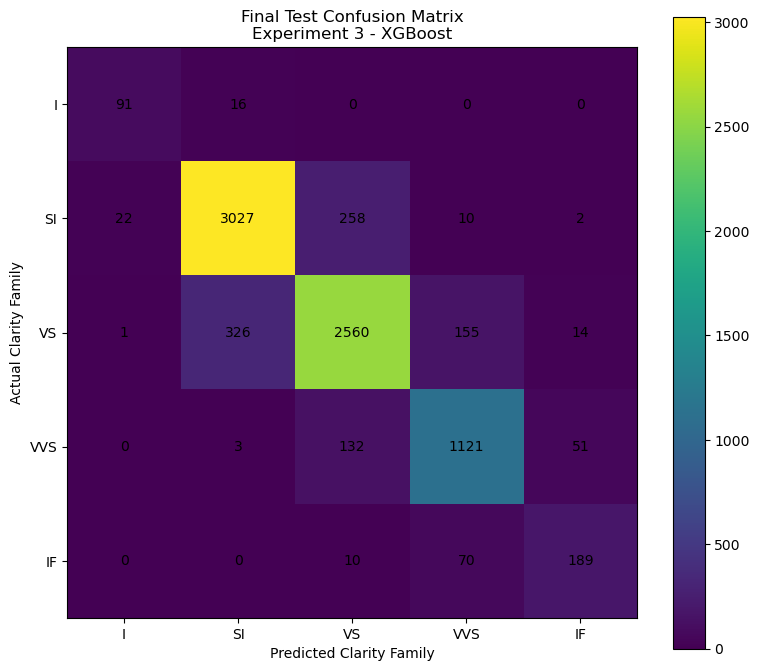

In [186]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(cm)

ax.set_title(
    f"Final Test Confusion Matrix\n{best_run}"
)

ax.set_xlabel("Predicted Clarity Family")
ax.set_ylabel("Actual Clarity Family")

ax.set_xticks(
    np.arange(len(CLARITY_CLASSES))
)

ax.set_yticks(
    np.arange(len(CLARITY_CLASSES))
)

ax.set_xticklabels(CLARITY_CLASSES)
ax.set_yticklabels(CLARITY_CLASSES)

for i in range(len(CLARITY_CLASSES)):
    for j in range(len(CLARITY_CLASSES)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax
)

plt.tight_layout()
plt.show()

In [187]:
validation_macro_f1 = best_row["Macro_F1"]
validation_accuracy = best_row["Accuracy"]

test_macro_f1 = final_test_results["Macro_F1"]
test_accuracy = final_test_results["Accuracy"]

final_comparison = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],
    "Accuracy": [
        validation_accuracy,
        test_accuracy
    ],
    "Macro_F1": [
        validation_macro_f1,
        test_macro_f1
    ]
})

display(final_comparison)

,Dataset,Accuracy,Macro_F1
0,Validation,86.682388,83.399406
1,Test,86.721271,82.825967


## Classification Conclusion

Three feature configurations were evaluated using Artificial Neural Networks,
Random Forest, and XGBoost.

Experiment 1 measured performance using physical and categorical information
without price.

Experiment 2 investigated whether adding raw diamond price improved clarity
classification.

Experiment 3 investigated whether price-relative engineered features provided
additional predictive information.

The models were compared using the validation set, with Macro F1 used as the
primary model-selection metric.

The strongest validation model was selected and evaluated once on the
previously untouched test set.

The final test results provide an estimate of how well the selected model
generalizes to unseen diamond observations.